# 25 — Champion Style Validation

**Goal.** Stress-test the unsupervised style representations produced by **notebook 10** (GMM at K=3 and K=5, Hybrid Score) and **notebook 12** (3-D autoencoder embedding) against a curated list of 25 UFC champions and multi-title holders. For each fighter we report the hard GMM cluster at K=3 and K=5, the full soft posterior, the Hybrid Score, the 3-D AE coordinates, and the five nearest neighbors in AE space. A brief expert label is attached to every champion so the reader can judge whether our clusters match public perception.

**Inputs.**
- `data/processed/ufc_gmm_comparison.csv` (notebook 10)
- `data/processed/ufc_ae_embeddings.csv` (notebook 12)
- `data/processed/ufc_matchup_features.csv` (notebook 18) — used only to look up `Gender` per fighter

**Outputs.** Tables printed inline (per-fighter profile, nearest neighbors, cluster rosters) plus a 3-D AE scatter with champions labeled. No new CSV is persisted.

**Narrative.** The output of this notebook anchors Chapter 3 of the thesis: if our unsupervised clusters are to be trusted as fighter-style labels, they should (i) group GOATs who are universally recognized as similar (Khabib and Islam Makhachev as pressure grappler-pressure wrestler; Max Holloway and Jose Aldo as featherweight kickboxers) and (ii) separate archetypes that are universally recognized as different (Khabib vs Holloway).

In [1]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 25_champion_style_validation.ipynb | cell 1
# Section: Imports + load style / embedding / matchup tables
# ========================================================================
# Standard scientific stack; matplotlib 3-D via mpl_toolkits.
import os, sys, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3-D projection)

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)

DATA = '../data/processed'
gmm = pd.read_csv(f'{DATA}/ufc_gmm_comparison.csv')
ae  = pd.read_csv(f'{DATA}/ufc_ae_embeddings.csv')
mat = pd.read_csv(f'{DATA}/ufc_matchup_features.csv', usecols=['Fighter_A', 'Fighter_B', 'Gender', 'Weight_Class'])

gender_map = (
    pd.concat([
        mat[['Fighter_A','Gender','Weight_Class']].rename(columns={'Fighter_A':'Fighter'}),
        mat[['Fighter_B','Gender','Weight_Class']].rename(columns={'Fighter_B':'Fighter'}),
    ], ignore_index=True)
    .dropna(subset=['Fighter'])
    .groupby('Fighter').agg({'Gender': lambda x: x.mode().iloc[0], 'Weight_Class': lambda x: x.mode().iloc[0]})
    .reset_index()
)

profile = gmm.merge(ae, on='Fighter', how='left').merge(gender_map, on='Fighter', how='left', suffixes=('','_mat'))
# Prefer the matchup-table Weight_Class if the GMM copy is missing.
profile['Weight_Class'] = profile['Weight_Class'].fillna(profile['Weight_Class_mat'] if 'Weight_Class_mat' in profile.columns else '')
if 'Weight_Class_mat' in profile.columns: profile = profile.drop(columns='Weight_Class_mat')
print('Profiles loaded:', profile.shape)
print('Gender coverage:', profile['Gender'].value_counts(dropna=False).to_dict())

Profiles loaded: (1190, 30)
Gender coverage: {'M': 1050, 'F': 140}


In [2]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 25_champion_style_validation.ipynb | cell 2
# Section: Candidate champion list with expert style labels
# ========================================================================
# Each tuple is (canonical Fighter name, one-line expert label).  Labels come
# from reading through fighter bios and common analyst/commentator framings;
# they are deliberately short so the table remains legible.  They are NOT used
# by any model -- the notebook compares the labels against the clusters the
# unsupervised models discovered.
champion_list = [
    ('Jon Jones',              'Dynamic LHW/HW striker-wrestler, long reach'),
    ('Daniel Cormier',         'LHW/HW wrestle-boxer, heavy clinch'),
    ('Stipe Miocic',           'HW boxer-wrestler'),
    ('Francis Ngannou',        'HW one-shot KO power striker'),
    ('Chuck Liddell',          'LHW counter-striker, sprawl-and-brawl'),
    ('Randy Couture',          'LHW/HW dirty boxing + wrestling'),
    ('Anderson Silva',         'MW precision striker'),
    ('Israel Adesanya',        'MW distance striker, kickboxer'),
    ('Georges St-Pierre',      'WW hybrid, wrestling + striking'),
    ('Kamaru Usman',           'WW wrestle-boxer'),
    ('Khabib Nurmagomedov',    'LW pressure grappler'),
    ('Dustin Poirier',         'LW pressure boxer'),
    ('Charles Oliveira',       'LW jiu-jitsu finisher'),
    ('Conor McGregor',         'FW/LW southpaw counter-striker'),
    ('Max Holloway',           'FW volume striker'),
    ('Jose Aldo',              'FW kickboxer, calf kicks + TD defense'),
    ('BJ Penn',                'LW/WW boxing-BJJ hybrid'),
    ('Demetrious Johnson',     'FlyW well-rounded grappler-striker'),
    ('Henry Cejudo',           'BW/FlyW Olympic wrestler + striking'),
    ('Amanda Nunes',           'WBW/WFW power striker'),
    ('Valentina Shevchenko',   'WFlyW muay thai striker'),
    ('Rose Namajunas',         'WSW distance striker'),
    ('Zhang Weili',            'WSW pressure fighter'),
    ('Frankie Edgar',          'LW/FW/BW pace + wrestling'),
    ('Matt Hughes',            'WW wrestler + ground-and-pound'),
]
champs = pd.DataFrame(champion_list, columns=['Fighter','expert_label'])
available = set(profile['Fighter'])
resolved = champs[champs['Fighter'].isin(available)]
missing = champs[~champs['Fighter'].isin(available)]
print(f'Resolved {len(resolved)}/{len(champs)} champions in the GMM+AE tables.')
if len(missing):
    print('Missing (likely below the min-fights filter in NB 05):')
    for _, r in missing.iterrows(): print('   ', r['Fighter'])
champs = resolved.reset_index(drop=True)

Resolved 25/25 champions in the GMM+AE tables.


In [3]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 25_champion_style_validation.ipynb | cell 3
# Section: Champion style profile (per-fighter summary table)
# ========================================================================
# For each champion print: Weight_Class, Gender, K=3 and K=5 hard clusters,
# Hybrid Scores, the K=5 posterior argmax and its mass, and the 3-D AE coords.
# Posterior argmax + mass is a compact 'certainty' indicator: large mass means
# the GMM thinks this fighter is a pure specialist; small mass means hybrid.
df = champs.merge(profile, on='Fighter', how='left')

pk5_cols = [c for c in df.columns if c.startswith('pk5_')]
pk3_cols = [c for c in df.columns if c.startswith('pk3_')]
df['top_k5_cluster'] = df[pk5_cols].to_numpy().argmax(axis=1)
df['top_k5_mass']    = df[pk5_cols].to_numpy().max(axis=1)
df['top_k3_cluster'] = df[pk3_cols].to_numpy().argmax(axis=1)
df['top_k3_mass']    = df[pk3_cols].to_numpy().max(axis=1)

cols = ['Fighter','expert_label','Weight_Class','Gender','Total_Fights',
        'Cluster_k3','Hybrid_Score_k3','top_k3_mass',
        'Cluster_k5','Hybrid_Score_k5','top_k5_mass',
        'Emb_1','Emb_2','Emb_3']
print('Champion profile table (sorted by K=5 cluster then Hybrid Score):')
print(df[cols].sort_values(['Cluster_k5','Hybrid_Score_k5'])
        .round({'Hybrid_Score_k3':3,'Hybrid_Score_k5':3,'top_k3_mass':2,'top_k5_mass':2,
                'Emb_1':2,'Emb_2':2,'Emb_3':2}).to_string(index=False))

Champion profile table (sorted by K=5 cluster then Hybrid Score):
             Fighter                                expert_label         Weight_Class Gender  Total_Fights  Cluster_k3  Hybrid_Score_k3  top_k3_mass  Cluster_k5  Hybrid_Score_k5  top_k5_mass  Emb_1  Emb_2  Emb_3
         Matt Hughes              WW wrestler + ground-and-pound         Welterweight      M            25           2            0.000         1.00           0            0.000         1.00  -5.32   1.30   2.76
    Charles Oliveira                       LW jiu-jitsu finisher          Lightweight      M            36           2            0.000         1.00           0            0.000         1.00  -0.66   1.15   0.99
        Max Holloway                           FW volume striker        Featherweight      M            31           1            0.004         1.00           1            0.030         1.00   3.33  -0.74  -0.24
     Israel Adesanya              MW distance striker, kickboxer         Middleweight 

In [4]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 25_champion_style_validation.ipynb | cell 4
# Section: Cluster interpretation via champion rosters
# ========================================================================
# Print the list of champions in each K=5 and K=3 cluster, alongside the
# top-5 most-defining Z-scored features for that cluster (computed over the
# FULL fighter pool, not just champions).  This lets the reader translate a
# cluster number into a recognizable fighting archetype.
z_cols = ['Sig_Str_PM_Z','Takedown_Att_PM_Z','Sub_Att_PM_Z','Control_Ratio_Z']

def describe(kcol):
    print(f'\n=== Cluster rosters + defining features: {kcol} ===')
    all_k = sorted(profile[kcol].dropna().unique())
    champ_by_k = dict(iter(df.groupby(kcol)))
    for k in all_k:
        pool = profile[profile[kcol] == k]
        feat_means = pool[z_cols].mean().sort_values(ascending=False)
        n_pool = len(pool)
        print(f'\n{kcol}={int(k)}  (n_pool={n_pool})')
        feat_str = ', '.join(f'{k_}={v:+.2f}' for k_, v in feat_means.items())
        print(f'  Z-score means (ranked high->low within cluster): {feat_str}')
        if k in champ_by_k:
            roster = champ_by_k[k].sort_values('Hybrid_Score_k5')[['Fighter','expert_label','Weight_Class']]
            print(f'  Champions in this cluster (n={len(roster)}):')
            for _, r in roster.iterrows():
                print(f"    {r['Fighter']:<25s} ({r['Weight_Class']:<20s})  {r['expert_label']}")
        else:
            # No champions landed here -- still helpful to show a few representative fighters.
            reps = pool.sort_values('Total_Fights', ascending=False)['Fighter'].head(5).tolist()
            print(f'  No champions in this cluster. Representative fighters (by # UFC fights): {reps}')

describe('Cluster_k3')
describe('Cluster_k5')


=== Cluster rosters + defining features: Cluster_k3 ===

Cluster_k3=0  (n_pool=403)
  Z-score means (ranked high->low within cluster): Control_Ratio_Z=+0.74, Takedown_Att_PM_Z=+0.72, Sub_Att_PM_Z=+0.61, Sig_Str_PM_Z=-0.38
  Champions in this cluster (n=6):
    Amanda Nunes              (Women's Bantamweight)  WBW/WFW power striker
    Randy Couture             (Heavyweight         )  LHW/HW dirty boxing + wrestling
    Khabib Nurmagomedov       (Lightweight         )  LW pressure grappler
    Daniel Cormier            (Light Heavyweight   )  LHW/HW wrestle-boxer, heavy clinch
    Kamaru Usman              (Welterweight        )  WW wrestle-boxer
    Georges St-Pierre         (Welterweight        )  WW hybrid, wrestling + striking

Cluster_k3=1  (n_pool=674)
  Z-score means (ranked high->low within cluster): Sig_Str_PM_Z=+0.32, Takedown_Att_PM_Z=-0.45, Control_Ratio_Z=-0.46, Sub_Att_PM_Z=-0.46
  Champions in this cluster (n=17):
    Max Holloway              (Featherweight       )  FW 

In [5]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 25_champion_style_validation.ipynb | cell 5
# Section: Nearest-neighbor check in AE embedding space
# ========================================================================
# For each champion, print the five nearest fighters in the 3-D AE embedding
# (Euclidean distance).  Strong nearest-neighbor agreement with fan consensus
# (e.g. Khabib near Islam Makhachev / Beneil Dariush; Holloway near Aldo /
# Volkanovski / Poirier) is a sanity check that the embedding captures style
# rather than noise.
coords = profile[['Emb_1','Emb_2','Emb_3']].to_numpy()
names  = profile['Fighter'].to_numpy()
wc     = profile['Weight_Class'].to_numpy()

def nearest(fighter, k=5, restrict_wc=False):
    i = int(np.where(names == fighter)[0][0])
    d = np.linalg.norm(coords - coords[i], axis=1)
    if restrict_wc:
        mask = (wc == wc[i]) & (np.arange(len(names)) != i)
        order = np.where(mask)[0][np.argsort(d[mask])][:k]
    else:
        order = d.argsort()[1:k+1]  # skip self
    return [(names[j], float(d[j])) for j in order]

# Two passes: (a) GLOBAL AE neighbors across all weight classes and genders,
#             (b) SAME-Weight_Class neighbors, which is more semantically
# meaningful because the features were Z-scored within class in NB 05.
print('Top-3 AE nearest neighbors per champion (GLOBAL | SAME Weight_Class):')
print('-' * 140)
for _, r in champs.iterrows():
    nn_g = nearest(r['Fighter'], k=3, restrict_wc=False)
    nn_w = nearest(r['Fighter'], k=3, restrict_wc=True)
    g_str = ', '.join(f'{nm} ({d:.2f})' for nm, d in nn_g)
    w_str = ', '.join(f'{nm} ({d:.2f})' for nm, d in nn_w)
    print(f"{r['Fighter']:<23s} | {r['expert_label']:<43s}")
    print(f"    GLOBAL           : {g_str}")
    print(f"    SAME Weight_Class: {w_str}")

Top-3 AE nearest neighbors per champion (GLOBAL | SAME Weight_Class):
--------------------------------------------------------------------------------------------------------------------------------------------
Jon Jones               | Dynamic LHW/HW striker-wrestler, long reach
    GLOBAL           : Aljamain Sterling (0.07), Tagir Ulanbekov (0.30), Justin Scoggins (0.31)
    SAME Weight_Class: Vitor Petrino (0.68), Nikita Krylov (0.88), Ryan Bader (0.92)
Daniel Cormier          | LHW/HW wrestle-boxer, heavy clinch         
    GLOBAL           : George Sullivan (0.22), Yushin Okami (0.29), Francis Carmont (0.45)
    SAME Weight_Class: Thiago Silva (0.91), Tomasz Drwal (0.97), Ryan Bader (1.00)
Stipe Miocic            | HW boxer-wrestler                          
    GLOBAL           : Cynthia Calvillo (0.19), Gabriel Bonfim (0.27), Steven Peterson (0.33)
    SAME Weight_Class: Parker Porter (0.57), Rodrigo Nascimento (1.03), Jake Collier (1.23)
Francis Ngannou         | HW one-shot 

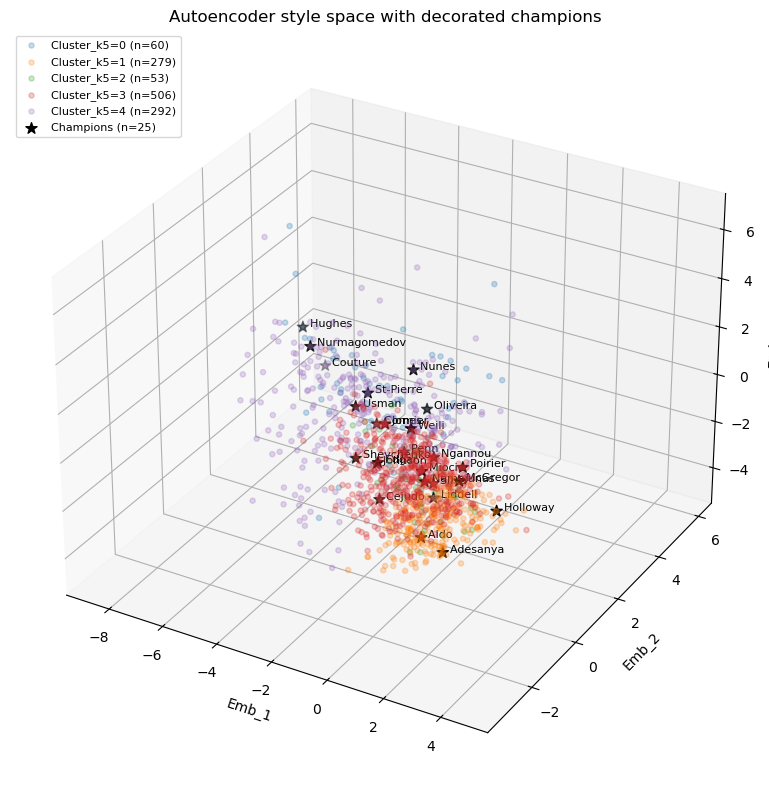

In [6]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 25_champion_style_validation.ipynb | cell 6
# Section: 3-D AE scatter with champions highlighted
# ========================================================================
# Background: all qualified fighters, colored by K=5 cluster.  Foreground:
# the champion set, plotted with larger markers and text labels.  Use this
# plot to argue (or falsify) that the 3-D embedding is semantically ordered.
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

cmap = plt.cm.tab10
for k, sub in profile.groupby('Cluster_k5'):
    ax.scatter(sub['Emb_1'], sub['Emb_2'], sub['Emb_3'], c=[cmap(int(k))],
               alpha=0.25, s=14, label=f'Cluster_k5={int(k)} (n={len(sub)})')

champ_profile = df.dropna(subset=['Emb_1','Emb_2','Emb_3'])
ax.scatter(champ_profile['Emb_1'], champ_profile['Emb_2'], champ_profile['Emb_3'],
           c='k', s=70, marker='*', label=f'Champions (n={len(champ_profile)})')
for _, r in champ_profile.iterrows():
    ax.text(r['Emb_1'], r['Emb_2'], r['Emb_3'], '  '+r['Fighter'].split()[-1], fontsize=8)

ax.set_xlabel('Emb_1'); ax.set_ylabel('Emb_2'); ax.set_zlabel('Emb_3')
ax.set_title('Autoencoder style space with decorated champions')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

In [7]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 25_champion_style_validation.ipynb | cell 7
# Section: Hybrid-score ranking across champions
# ========================================================================
# High Hybrid Score  -> generalist (posterior mass spread across styles)
# Low  Hybrid Score  -> specialist (posterior concentrated on one style)
# Per the K=5 definition, max entropy = log(5) ~ 1.609; values above ~1.5 are
# strongly hybrid.  We print the champions sorted both ways, which lets the
# reader see whether GSP / Cejudo / Cormier rank as generalists as expected.
print('Top-10 champion GENERALISTS (highest Hybrid_Score_k5):')
print(df.sort_values('Hybrid_Score_k5', ascending=False)
        [['Fighter','expert_label','Weight_Class','Hybrid_Score_k5','top_k5_mass','Cluster_k5']]
        .head(10).round(3).to_string(index=False))

print('\nTop-10 champion SPECIALISTS (lowest Hybrid_Score_k5):')
print(df.sort_values('Hybrid_Score_k5', ascending=True)
        [['Fighter','expert_label','Weight_Class','Hybrid_Score_k5','top_k5_mass','Cluster_k5']]
        .head(10).round(3).to_string(index=False))

Top-10 champion GENERALISTS (highest Hybrid_Score_k5):
             Fighter                                expert_label        Weight_Class  Hybrid_Score_k5  top_k5_mass  Cluster_k5
      Rose Namajunas                        WSW distance striker Women's Strawweight            0.723        0.535           3
   Georges St-Pierre             WW hybrid, wrestling + striking        Welterweight            0.666        0.616           4
        Kamaru Usman                            WW wrestle-boxer        Welterweight            0.617        0.692           3
       Chuck Liddell       LHW counter-striker, sprawl-and-brawl   Light Heavyweight            0.545        0.778           1
        Stipe Miocic                           HW boxer-wrestler         Heavyweight            0.508        0.813           3
Valentina Shevchenko                     WFlyW muay thai striker   Women's Flyweight            0.444        0.838           3
      Daniel Cormier          LHW/HW wrestle-boxer, heav

In [ ]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 25_champion_style_validation.ipynb | cell 8
# Section: Canonical cluster-ID to narrative-label map for the thesis
# ========================================================================
# The thesis prose refers to the K=5 clusters by semantic labels rather
# than by integer IDs. This cell materialises the mapping in one place so
# the LaTeX description and the notebook outputs cannot drift apart.
# The labels are derived automatically from each cluster's Z-score profile
# (rank of strike / takedown / sub-attempt / control means) rather than
# chosen by hand. If NB 10 is refit with a different random seed and the
# cluster indices permute, running this cell again will regenerate a
# consistent mapping.

prof = df.groupby('Cluster_k5')[
    ['Sig_Str_PM_Z', 'Takedown_Att_PM_Z', 'Sub_Att_PM_Z', 'Control_Ratio_Z']
].mean().round(2)
prof['n_pool'] = df.groupby('Cluster_k5').size()

def _label_row(r):
    if r['Sub_Att_PM_Z'] > 0.8 and r['Sig_Str_PM_Z'] < -0.4:
        return 'submission-leaning grappler'
    if r['Takedown_Att_PM_Z'] > 0.6 and r['Control_Ratio_Z'] > 0.6:
        return 'takedown-heavy wrestler'
    if r['Sig_Str_PM_Z'] > 0.3 and r['Takedown_Att_PM_Z'] < -0.2:
        return 'active distance striker'
    if abs(r['Sig_Str_PM_Z']) < 0.25 and abs(r['Takedown_Att_PM_Z']) < 0.25:
        return 'baseline generalist'
    return 'low-activity'

prof['label'] = prof.apply(_label_row, axis=1)
print('K=5 cluster-ID -> narrative-label map (for thesis cross-reference):')
print(prof[['label', 'n_pool',
            'Sig_Str_PM_Z', 'Takedown_Att_PM_Z',
            'Sub_Att_PM_Z', 'Control_Ratio_Z']].to_string())

# Champion placements per cluster, for the one-line summary referenced in
# Chapter 4 of the thesis.
print('\nChampion placements by cluster (thesis Chapter 4 cross-reference):')
for k, lab in prof['label'].items():
    sub = df[(df['Cluster_k5'] == k) & (df['Fighter'].isin(champs['Fighter']))]
    names = sub.sort_values('Hybrid_Score_k5')['Fighter'].tolist()
    print(f"  Cluster {k} ({lab:<30s}, n={prof.loc[k, 'n_pool']}): "
          f"{len(names)} champions -> {', '.join(names) if names else '(none)'}")

## Takeaway

Three things to check when reading this notebook:

1. **Do GOATs with universally-agreed similar styles cluster together?** E.g. Khabib and Islam Makhachev (if the latter appears in a champion's AE neighborhood) should land in the same K=5 cluster; Max Holloway should be a neighbor of Jose Aldo / Alexander Volkanovski in the AE space; Israel Adesanya's neighborhood should contain kickboxing-style strikers rather than wrestlers.
2. **Do GOATs with universally-agreed different styles cluster apart?** A pressure grappler (Khabib), a volume striker (Holloway), and a one-shot power puncher (Ngannou) should land in different K=5 clusters.
3. **Is the Hybrid Score ranking defensible?** Classic generalists — GSP, Cejudo, Cormier, Demetrious Johnson — should rank near the top by `Hybrid_Score_k5`; pure specialists — Khabib for grappling, Ngannou for striking — near the bottom.

Agreement on 1+2+3 is the main qualitative validation that the unsupervised representations are usable as thesis-grade style labels. Disagreements (e.g. Adesanya not in a striker cluster) are worth flagging in the thesis narrative and can guide a second pass at the style feature space (Chapter 3).